In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv('./data/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df = df.drop('PassengerId', axis=1)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')
encoder = OrdinalEncoder(categories= [df['Title'].unique()] )
df['Title'] = encoder.fit_transform(df[['Title']])

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Cabin'].fillna("UnKnown", inplace=True)


df['Cabin'] = df['Cabin'].apply(lambda x: x[0] if x != "UnKnown" else "U")
encoder = OrdinalEncoder(categories=[['A','B','C','D','E','F','G','T','U']])
df['Cabin'] = encoder.fit_transform(df[['Cabin']])

def get_ticket_prefix(ticket):
        ticket = ticket.replace('.', '').replace('/', '')
        parts = ticket.split()
        prefix = parts[0] if not parts[0].isdigit() else "NONE"
        return prefix

df['TicketPrefix'] = df['Ticket'].apply(get_ticket_prefix)

encoder = OrdinalEncoder(categories= [df['TicketPrefix'].unique()] )
df['TicketPrefix'] = encoder.fit_transform(df[['TicketPrefix']])


df = df.drop('Ticket', axis=1)

df['Embarked'].fillna('S', inplace=True)
encoder = OrdinalEncoder(categories=[['S', 'C', 'Q']])
df['Embarked'] = encoder.fit_transform(df[['Embarked']])

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_14300\284254485.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')
C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_14300\284254485.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna("UnKnown", inplace=True)
C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_14300\284254485.py:28: FutureWarning: A value is tryi

In [23]:
df =df.drop("Name", axis=1)

In [24]:
df.iloc[:, 1:]

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Title,TicketPrefix
0,3,0,22.0,1,0,7.2500,8.0,0.0,0.0,0.0
1,1,1,38.0,1,0,71.2833,2.0,1.0,1.0,1.0
2,3,1,26.0,0,0,7.9250,8.0,0.0,2.0,2.0
3,1,1,35.0,1,0,53.1000,2.0,0.0,1.0,3.0
4,3,0,35.0,0,0,8.0500,8.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,8.0,0.0,5.0,3.0
887,1,1,19.0,0,0,30.0000,1.0,0.0,2.0,3.0
888,3,1,NaN,1,2,23.4500,8.0,0.0,2.0,11.0
889,1,0,26.0,0,0,30.0000,2.0,1.0,0.0,3.0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2, random_state=42)

# DecisionTree

In [26]:
from sklearn import tree

dt = tree.DecisionTreeClassifier(max_depth=10, min_samples_split= 5)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


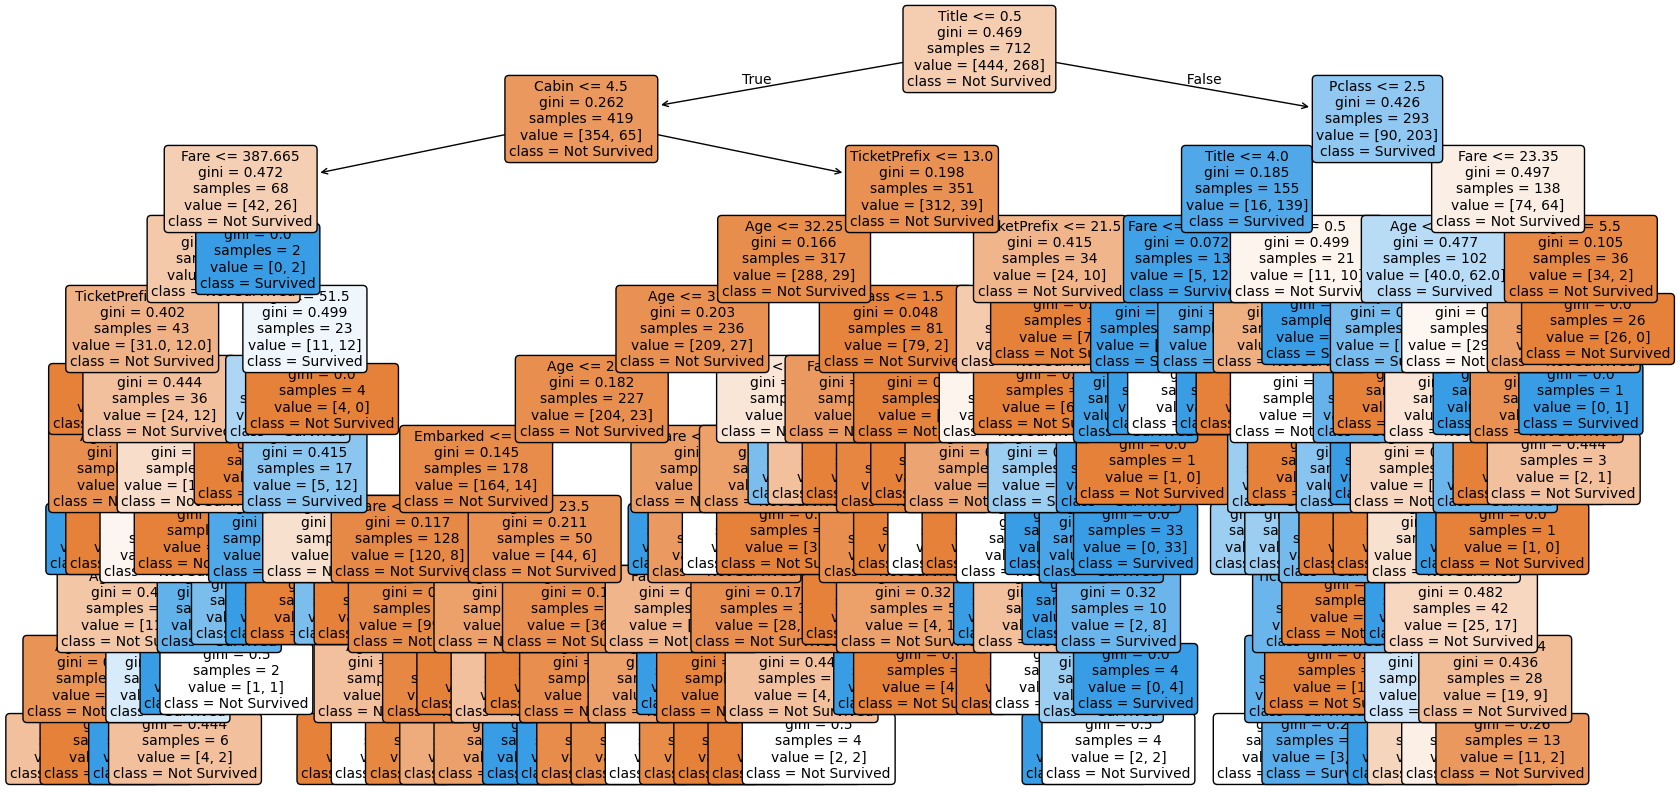

In [27]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # chỉnh kích thước hình
tree.plot_tree(dt, 
               filled=True,        # tô màu theo lớp
               feature_names=X_train.columns,  # tên đặc trưng
               class_names=['Not Survived', 'Survived'],  # tên nhãn
               rounded=True, 
               fontsize=10)
plt.show()


## tìm tham số tối ưu

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)


grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='accuracy',    # hoặc 'f1', 'recall', v.v.
    n_jobs=-1,             # chạy song song
    verbose=2    ,          # in log ra để theo dõi tiến trình
    return_train_score=True
)
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'entropy'


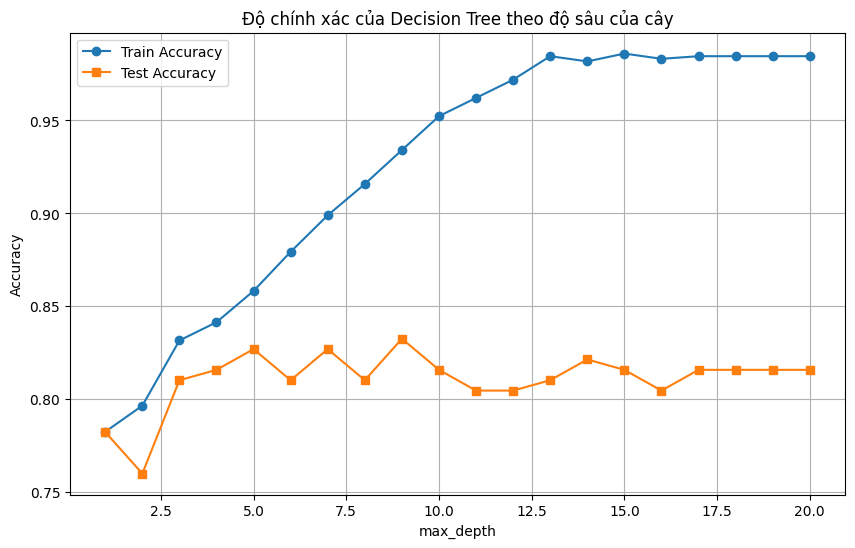

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Giả sử bạn đã có:
# X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2, random_state=42)

max_depths = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    # Độ chính xác train và test
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.plot(max_depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(max_depths, test_scores, marker='s', label='Test Accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Độ chính xác của Decision Tree theo độ sâu của cây')
plt.legend()
plt.grid(True)
plt.show()


# RandomForest

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

In [40]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,60


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_14300\1889697650.py:12: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


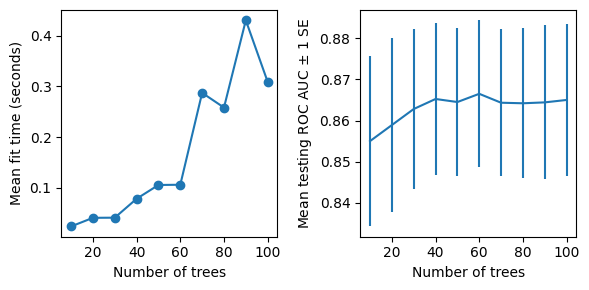

In [41]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

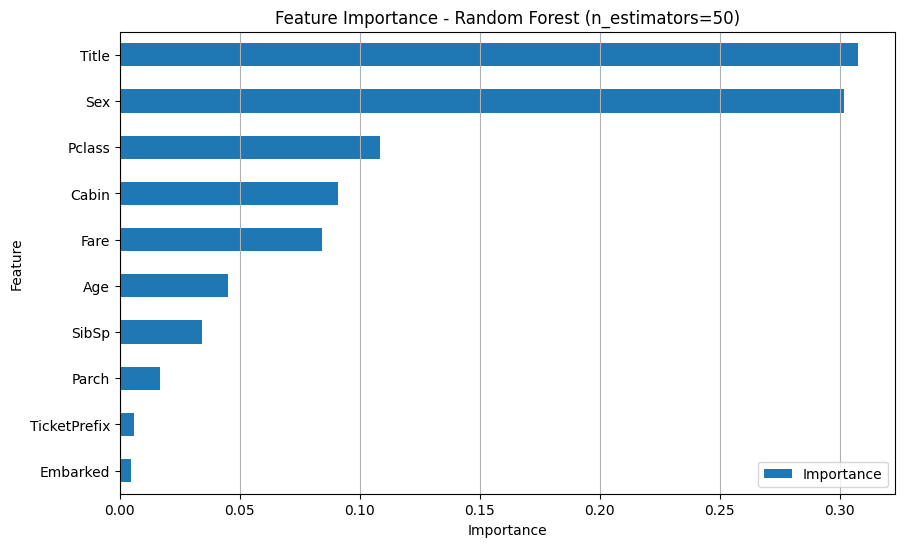

In [ ]:

features_response = X_train.columns


feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=features_response)


feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(10,6))
plt.title('Feature Importance - Random Forest (n_estimators=50)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.show()
